In [3]:
# transferable code functions
import numpy as np
import scipy.signal as scisig
from omegaconf import DictConfig, OmegaConf
from http.server import BaseHTTPRequestHandler, HTTPServer
from functools import partial
import json

trn_cfg = OmegaConf.load("hyper_params.yaml")



def padding(layer:np.ndarray, mode:str = 'zero', pad_size:int = 1):

    for i in range(pad_size):

        padded_ly_size = (layer.shape[0]+2, layer.shape[1]+2)
        padded_ly = np.zeros(padded_ly_size)
        padded_ly[1:-1,1:-1] = layer
    
        if mode == 'same':
            padded_ly[0,1:-1] = layer[0,:]
            padded_ly[-1,1:-1] = layer[-1,:]

            padded_ly[1:-1,0] = layer[:,0]
            padded_ly[1:-1,-1] = layer[:,-1]

            padded_ly[0,0] = layer[0,0]
            padded_ly[0,-1] = layer[0,-1]
            padded_ly[-1,0] = layer[-1,0]
            padded_ly[-1,-1] = layer[-1,-1]
        layer = padded_ly

    return(padded_ly)

def convolve(input:np.ndarray, kernel:np.ndarray, pad_mode:str = 'zero', pad_size:int = 666, conv_mode:str="valid"):
    if pad_mode !="none":
        if pad_size == 666:
            pad_size = kernel.shape[0]//2
        input = padding(input, pad_mode, pad_size)
    k_shp = kernel.shape
    #print(input.shape)
    result = scisig.convolve(input, kernel, mode=conv_mode, method="fft")

    return(result)

def patch_convolve(input:np.ndarray, patch_shape:tuple, error_array:np.ndarray, pad_mode:str = 'zero', pad_size:int = 666, conv_mode:str="valid"):
    if pad_mode !="none":
        if pad_size == 666:
            pad_size = patch_shape[0]//2
        input = padding(input, pad_mode, pad_size)
    
    error_patch_arr = np.zeros(shape=(*error_array.shape, *patch_shape))

    for i in range(error_array.shape[0]):
        for j in range(error_array.shape[1]):
            error_patch_arr[i,j,:,:] = input[i:i+patch_shape[0], j:j+patch_shape[1]] * error_array[i,j]
    kernel_delta = np.sum(error_patch_arr, axis=(0,1))
    return(kernel_delta)

def fast_patch_convolve(input:np.ndarray, patch_shape:tuple, error_array:np.ndarray, 
                        pad_mode:str = 'zero', pad_size:int = 666, conv_mode:str="valid"):
    from numpy.lib.stride_tricks import sliding_window_view
    if pad_mode !="none":
        if pad_size == 666:
            pad_size = patch_shape[0]//2
        input = padding(input, pad_mode, pad_size)

    patches = sliding_window_view(input, (3,3))
    op1 = patches * error_array[:,:, np.newaxis, np.newaxis] #Need to understand this better

    dW = np.sum(op1, axis=(0,1))
    #dw is the delta in the filter/kernel/patch
    return(dW)

def pool(input:np.ndarray, stride = 2, mode = "max"):
    shape = (input.shape[0]//stride, input.shape[1]//stride)
    output = np.zeros(shape)
    source_mask = np.zeros_like(input)

    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            region = input[i*stride:i*stride+stride,j*stride:j*stride+stride]
            if mode =="max":
                local_max = np.max(region) 
                output[i,j] = local_max
                local_mask = (region == local_max)

                
                #look at that absolute index fuckery
            elif mode =="mean":
                output[i,j] = np.mean(region)
                local_mask = np.ones_like(region)

            else:
                raise ValueError(f"Unsupported pooling mode: {mode}")    

            source_mask[i*stride:i*stride+stride,j*stride:j*stride+stride] = local_mask
    return(source_mask, output)

def sigmond(input):
    return( 1/(1+np.exp(-input)))

def sigmond_prime(input):
    return(sigmond(input) * (1-sigmond(input)))

def ReLU(input):
    return(np.maximum(0, input))

def ReLU_prime(input):
    return(input > 0).astype(input.dtype)

def LeakyReLU(input, alpha = 0.01):
    return np.where(input > 0, input, alpha * input)

def LeakyReLU_prime(input, alpha = trn_cfg.leaky_ReLU_alpha):
    return np.where(input > 0, 1, alpha)

def deep_copy_mat_list (list_to_copy, propigate_cell_vals=True):
    #creates a copy of a list containing numpy arrays of varible size, ethier as empty arrays or with the same values
    
    new_list = []
    if propigate_cell_vals:
        for items in list_to_copy:
            new_list.append(items)
    else:
        for items in list_to_copy:
            new_list.append(np.zeros_like(items))       

    return(new_list)

def label_to_output(int) -> np.ndarray:
    outlayer = np.zeros(shape=(10), dtype=np.float32)
    outlayer[int] = 10000000
    return(outlayer)

def label_vec_to_output(inputs: np.ndarray) -> np.ndarray:
    # Create an identity matrix of size 10 and index into 
    scale_factor = 1
    return (np.eye(10, dtype=np.int32)[inputs] *scale_factor)


def create_batch(trn_cfg, image_file, label_file):
    """
    Given a hyper parameter cfg object, a loaded image file, and label file, 
    reads from both files and returns:

    input_batch: an ndarray of shape (batch_size, image_size_height, image_size_width) of type float32
    
    label_batch: an ndarray of shape (batch_size, possible_labels) of type int64
    """
    image_buffer = image_file.read(trn_cfg.image_size[0] * trn_cfg.image_size[1] * trn_cfg.batch_size)
    image_batch = np.frombuffer(image_buffer, dtype=np.uint8).astype(np.float32)
    image_batch = np.reshape(image_batch, shape = (trn_cfg.batch_size, 
                                                    trn_cfg.image_size[0], 
                                                    trn_cfg.image_size[1]))
    label_buffer = label_file.read(trn_cfg.batch_size)
    label_pre_batch = np.frombuffer(label_buffer, dtype=np.uint8).astype(np.int64)
    label_batch = label_vec_to_output(label_pre_batch)

    return(image_batch, label_batch)

def loss(network_output_ly, expected_ly):
    #loss =  mean of all output neurons - the expected, squared
    loss_vec = ((network_output_ly - expected_ly)**2) / 2
    loss_sclr = np.sum((network_output_ly - expected_ly)**2)
    return(loss_sclr, loss_vec)

def clip_grad(grad:np.ndarray, max_normal_val =  2.0):
    norm = np.linalg.norm(grad) 
    if norm > max_normal_val:
        return grad * (max_normal_val / norm)
    else:
        return grad
    
def clip_activations(activations:np.ndarray, z_vals:np.ndarray, threshold = 10000):
    warnings = []
    if np.max(np.abs(activations)) > threshold:
        warnings.append("activation high value detected")
        activations = np.clip(activations, -1e3, 1e3)
    if np.isnan(activations).any():
        warnings.append("activation NaN detected")
    if np.isnan(z_vals).any():
        warnings.append("z value NaN detected")
    return activations, z_vals, warnings


In [4]:
import hydra #not currently used 
from omegaconf import DictConfig, OmegaConf
mdl_cfg = OmegaConf.load("model.yaml")
import numpy as np
from dataclasses import dataclass
from omegaconf import DictConfig
import scipy.signal as scisig
import logging
import threading
import server

logging.basicConfig(level=logging.ERROR)

def build_index_lookup(cfg: DictConfig):
    """
    Given a loaded OmegaConf config with a 'layers' section,
    build a lookup table: index -> (layer_name, layer_data).
    """
    blocks = cfg.blocks

    index_lookup = {
        block_data.index: (block_name, block_data)
        for block_name, block_data in blocks.items()
    }
    return index_lookup

class Input_block:
    def __init__(self, layer_shape, index, **kwargs): 
        #need to figure out how to properly use kwargs
        self.layer_shape = layer_shape
        self.index = index

        self.b_type = "input"
        self.ly_dim = len(layer_shape)
        self.activations = np.zeros(layer_shape, dtype=np.float32)
        self.z_values = np.zeros(layer_shape, dtype=np.float32)

    def backprop(self, expected:np.ndarray=None):
        return(0)

class FC_block:
    def __init__(self, prev_ly_shape, layer_shape, index, **kwargs): 
        #need to figure out how to properly use kwargs
        self.layer_shape = layer_shape
        self.index = index
        self.prev_ly_shape = prev_ly_shape

        self.b_type = "fc"
        self.ly_dim = len(layer_shape)
        self.input_size = np.prod(prev_ly_shape)
        self.output_size = np.prod(layer_shape)

        self.activations = np.zeros(layer_shape, dtype=np.float32)
        self.z_values = np.zeros(layer_shape, dtype=np.float32)
        self.biases = np.zeros(layer_shape, dtype=np.float32)

        self.weights = self._init_weights()
        self.W_delta = np.zeros_like(self.weights, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)


    def _init_weights(self, init=True):
        fan_in = self.input_size
        if init:
            weights = np.random.randn(self.input_size, self.output_size) * np.sqrt(2.0 / fan_in)
        else:
            weights = np.zeros(shape=(self.input_size, self.output_size), dtype=np.float32)
        return(weights)
    
    def forward(self, input):
        self.z_values = np.zeros(self.layer_shape, dtype=np.float32)
        self.activations = np.zeros(self.layer_shape, dtype=np.float32)

        flattened_input = input.flatten()
        flattened_z = np.dot(flattened_input, self.weights) + self.biases.flatten()
        self.z_values = flattened_z.reshape(self.layer_shape)
        self.activations = LeakyReLU(self.z_values)


        self.activations = LeakyReLU(self.z_values)

        self.activations, self.z_values, clip_warns = clip_activations(self.activations, self.z_values)
        if clip_warns:
            logging.warning(f"activations clip warning: {clip_warns} at layer {self.index}")

    def backprop(self, prior_activations:np.ndarray=None, prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        self.W_delta = np.zeros_like(self.weights, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)
        
        if expected is not None:
            del_l = (expected - self.activations) * LeakyReLU_prime(self.z_values)

        del_l_flatted = del_l.flatten()
        flattened_input = prior_activations.flatten()

        #old slower code that presveres dimensions
        #if len(self.prev_ly_shape) == 1:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((1),(0)))# * prior_z_vals
        #if len(self.prev_ly_shape) == 2:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((2),(0)))# * prior_z_vals
        #self.W_delta = np.tensordot(prior_activations, del_l, axes=0)

        self.W_delta = np.outer(flattened_input, del_l_flatted)
        assert self.W_delta.shape == self.weights.shape
        self.B_delta = del_l

        flattened_del_neg1 = np.dot(self.weights, del_l_flatted)
        del_l_neg1 = flattened_del_neg1.reshape(self.prev_ly_shape)


        return(del_l_neg1, self.W_delta, self.B_delta)

class FC_CONV_block:
    def __init__(self, prev_bk_shape, layer_shape, index, **kwargs): 
        #need to figure out how to properly use kwargs
        self.layer_shape = layer_shape
        self.index = index
        self.prev_bk_shape = prev_bk_shape

        self.b_type = "fc_conv"
        self.ly_dim = len(layer_shape)
        self.input_size = np.prod(prev_bk_shape)
        self.output_size = np.prod(layer_shape)

        self.activations = np.zeros(layer_shape, dtype=np.float32)
        self.z_values = np.zeros(layer_shape, dtype=np.float32)
        self.biases = np.zeros(layer_shape, dtype=np.float32)
        self.weights = self._init_weights()

        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)
        self.W_delta = np.zeros_like(self.weights, dtype=np.float32)

    def _init_weights(self, init=True):
        fan_in = self.input_size
        if init:
            weights = np.random.randn(self.input_size, self.output_size) * np.sqrt(2.0 / fan_in)
        else:
            weights = np.zeros(shape=(self.input_size, self.output_size), dtype=np.float32)
        return(weights)
    
    def forward(self, input):
        self.z_values = np.zeros(self.layer_shape)
        self.activations = np.zeros(self.layer_shape)

        flattened_input = input.flatten()
        flattened_z = np.dot(flattened_input, self.weights) + self.biases.flatten()
        self.z_values = flattened_z.reshape(self.layer_shape)
        self.activations = LeakyReLU(self.z_values)


        self.activations, self.z_values, clip_warns = clip_activations(self.activations, self.z_values)
        if clip_warns:
            logging.warning(f"activations clip warning: {clip_warns} at layer {self.index}")

    def backprop(self, prior_activations:np.ndarray=None, prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        self.W_delta = np.zeros_like(self.weights)
        self.B_delta = np.zeros_like(self.biases)
        
        if expected is not None:
            del_l = (expected - self.activations) * LeakyReLU_prime(self.z_values)
        
        #old slower code that presveres dimensions
        #if len(self.layer_shape) == 2:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((3,4),(0,1)))# * prior_z_vals
        #if len(self.layer_shape) == 1:
        #    del_l_neg1 = np.tensordot(self.weights, del_l, axes=((3),(0)))# * prior_z_vals
        #self.W_delta = np.tensordot(prior_activations, del_l, axes=0)
        #self.B_delta = del_l


        del_l_flatted = del_l.flatten()
        flattened_input = prior_activations.flatten()

        self.W_delta = np.outer(flattened_input, del_l_flatted)
        assert self.W_delta.shape == self.weights.shape
        self.B_delta = del_l

        flattened_del_neg1 = np.dot(self.weights, del_l_flatted)
        del_l_neg1 = flattened_del_neg1.reshape(self.prev_bk_shape)

        return(del_l_neg1, self.W_delta, self.B_delta)

class Conv_Block:
    def __init__(self, prev_bk_depth, num_filters, kernel_shape, stride, layer_shape, index):
        self.num_filters = num_filters
        self.kernel_shape = kernel_shape
        self.stride = stride
        self.layer_shape = layer_shape
        self.index = index
        self.prev_bk_depth = prev_bk_depth


        self.b_type = "conv"
        self.ly_dim = len(layer_shape)
        self.filters = self._init_filters(self.prev_bk_depth, self.num_filters, self.kernel_shape, init = True) #are of size (h,m,3,3) 
        self.z_values = np.zeros(shape=(self.num_filters, *self.layer_shape), dtype=np.float32)
        self.biases = np.zeros(shape=(self.num_filters,), dtype=np.float32) 
        self.activations = np.zeros_like(self.z_values, dtype=np.float32)
        self.W_delta = np.zeros_like(self.filters, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)#not sure about this

    def _init_feature_maps(self):
        feature_maps = np.zeros(shape=(self.num_filters, *self.layer_shape), dtype=np.float32)
        feature_map_z_vals = np.zeros_like(feature_maps, dtype=np.float32)  
        return(feature_maps, feature_map_z_vals)

    def _init_filters(self, prior_num_filters:int, num_filters:int, kernel_shape:tuple, init=True):
        if init:
            fan_in = self.prev_bk_depth * kernel_shape[0] * kernel_shape[1]
            filters = np.random.randn(prior_num_filters, num_filters, *kernel_shape) * np.sqrt(2/fan_in)
        else:
            filters = np.zeros((prior_num_filters, num_filters, *kernel_shape), dtype=np.float32)
        return (filters)

    def forward(self, input:np.ndarray):
        self.z_values = np.zeros(shape=(self.num_filters, *self.layer_shape), dtype=np.float32)       
        self.activations = np.zeros(shape=(self.num_filters, *self.layer_shape), dtype=np.float32)

        if len(input.shape) == 2:
            input = np.expand_dims(input, axis=0)
        for m in range(self.filters.shape[1]):
            for h in range(self.filters.shape[0]):
                self.z_values[m,:,:] += convolve(input[h,:,:], self.filters[h,m,:,:], conv_mode="valid")
            self.z_values[m,:,:] += self.biases[m]
        self.activations = LeakyReLU(self.z_values)

        self.activations, self.z_values, clip_warns = clip_activations(self.activations, self.z_values)
        if clip_warns:
            logging.warning(f"activations clip warning: {clip_warns} at layer {self.index}")

    def backprop(self, prior_activations:np.ndarray=None, prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        self.W_delta = np.zeros_like(self.filters, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.biases, dtype=np.float32)
        
        if len(prior_z_vals.shape) == 2:
            prior_z_vals = np.expand_dims(prior_z_vals, axis=0)
            #might not need this code
        if len(prior_activations.shape) == 2:
            prior_activations = np.expand_dims(prior_activations, axis=0)
            #might not need this code

        prior_z_prime = LeakyReLU_prime(prior_z_vals)
        neg1_error = np.zeros_like(prior_z_vals)
        self.B_delta = np.sum(del_l, axis=(1, 2))

        for m in range(self.filters.shape[1]):
            for h in range(self.filters.shape[0]):
                #backprop error:
                kernel = self.filters[h, m]
                flipped_kernel = np.flip(kernel, axis=(0, 1))
                back = scisig.correlate2d(del_l[m], flipped_kernel, mode="full")
                trimmed = back[1:-1, 1:-1]
                neg1_error[h] += trimmed
                self.W_delta[h,m,:,:] = scisig.convolve2d(prior_activations[h,:,:], del_l[m,:,:], mode="valid")
            
        del_l_neg1 = neg1_error * prior_z_prime
        return(del_l_neg1, self.W_delta, self.B_delta)

class Pooling_ly:
    def __init__(self, shape, prev_3D_shape, num_filters, index, stride:int=2, p_type:str="max"):
        self.index = index
        self.shape = shape
        self.depth = num_filters
        self.stride = stride
        self.p_type = p_type
        self.b_type = "pooling"

        self.prev_3D_shape = prev_3D_shape
        self.activations = np.ndarray(shape=(self.depth, *self.shape), dtype=np.float32)
        self.z_values = np.zeros_like(self.activations, dtype=np.float32)
        self.source_mask = np.zeros(shape=(self.prev_3D_shape))
        self.weights = np.ndarray(shape=(1,), dtype=np.float32)
        self.biases = np.ndarray(shape=(1,), dtype=np.float32)


    def pooling(self, input_act):
        if len(input_act.shape) == 2:
            input_act = np.expand_dims(input_act, axis=0)
        
        self.activations = np.zeros((input_act.shape[0], *self.shape), dtype=np.float32)
        self.source_mask = np.zeros(shape=(self.prev_3D_shape), dtype=np.float32)
        for i in range(input_act.shape[0]):
            self.source_mask[i], self.activations[i,:,:] = pool(input_act[i,:,:], stride=self.stride, mode=self.p_type)
        

    def forward(self, input):
        self.pooling(input)
        self.z_values = self.activations

    def backprop(self, prior_activations:np.ndarray=None, prior_z_vals:np.ndarray=None, del_l:np.ndarray=None, expected:np.ndarray=None):
        if expected is not None:
            raise NotImplementedError("Expected values should not be passed to pooling layers.")
        s = self.stride
        del_l_neg1 = np.repeat(np.repeat(del_l, s, axis=1), s, axis=2) * self.source_mask #should be expanded over axes 1,2. axis 0 is the feature map dim
        if self.p_type == "mean":
            del_l_neg1 /= (self.stride ** 2) 
        self.W_delta = np.zeros_like(self.activations, dtype=np.float32)        
        self.B_delta = np.zeros_like(self.activations, dtype=np.float32)
        return(del_l_neg1, self.W_delta, self.B_delta)

class NN:
    def __init__(self, config:DictConfig, blocks: list):
        self.config = config
        self.blocks = blocks

    @classmethod
    def create_network(cls, cfg:DictConfig, **kwargs):
        index_to_block = build_index_lookup(cfg)
        logging.info("creating network....")

        blocks = []
        for items in cfg.blocks:
            #print(items)
            block_name, block_data = index_to_block[cfg.blocks[items].index]
            

            if block_data.type == "input":
                blocks.append(Input_block(block_data.shape, block_data.index))
            if block_data.type == "fc":
                if prev_bk_data.type == "conv2D":
                    prev_bk_shp = (prev_bk_data.filters.filter_num, *prev_bk_data.shape)
                    blocks.append(FC_CONV_block(prev_bk_shp, block_data.shape, block_data.index))
                else:
                    blocks.append(FC_block(prev_bk_data.shape, block_data.shape, block_data.index))
            if block_data.type == "pool":
                prev_bk_shp = (prev_bk_data.filters.filter_num, *prev_bk_data.shape)
                blocks.append(Pooling_ly(block_data.shape, prev_bk_shp, prev_bk_data.filters.filter_num, block_data.index, block_data.stride, block_data.mode))

            if block_data.type == "conv2D":
                fltr = block_data.filters
                if prev_bk_data.type == "conv2D":
                    prev_bk_dpth = prev_bk_data.filters.filter_num
                elif prev_bk_data.type == "pool":
                    prev_bk_dpth = blocks[-1].depth
                else:
                    prev_bk_dpth = 1

                blocks.append(Conv_Block(prev_bk_dpth, fltr.filter_num, fltr.kernel_shape, fltr.stride, block_data.shape, block_data.index))

            prev_bk_name = block_name
            prev_bk_data = block_data

        logging.info("Done!")
        return cls(cfg, blocks)
    
    def forward(self, input_ly):
        self.blocks[0].activations = input_ly
        self.blocks[0].z_values = input_ly
        for index in range(len(self.blocks)):
            #print("\nindex: ", index)
            if index == 0:
                self.blocks[0].activations = input_ly
            else:
                self.blocks[index].forward(self.blocks[index-1].activations)
            #print(f"Block {index} activation max: {np.max(self.blocks[index].activations)}")
            #print(f"Block {index} activation min: {np.min(self.blocks[index].activations)}")

    def backprop(self, expected):
        #print("running backprop....")
        dW = []
        dB = []
        for index in range(len(self.blocks)-1, 0 , -1):


            #print("index: ", index)
            if index == len(self.blocks)-1:
                delL_back1, dW_tmp, dB_tmp = self.blocks[index].backprop(prior_activations = self.blocks[index-1].activations, 
                                                         prior_z_vals= self.blocks[index-1].z_values,
                                                         expected = expected
                                                         )
            else:
                delL_back1, dW_tmp, dB_tmp = self.blocks[index].backprop(prior_activations = self.blocks[index-1].activations, 
                                                         prior_z_vals= self.blocks[index-1].z_values,
                                                         del_l = delL_back1
                                                         )
            if self.blocks[index].b_type =="pooling":
                pass
            else:
                dW.append(dW_tmp)
                dB.append(dB_tmp)
        dW.reverse()
        dB.reverse()#doing this because they were created from back to front
        #print("Done!")
        return(dW, dB)

def batch_backprop(input_batch:np.ndarray, desired_output_batch:np.ndarray,
                    trn_cfg:DictConfig, mdl_cfg:DictConfig, n_net:NN):
    batch_dW = []
    batch_dB = []
    batch_loss = np.ndarray((trn_cfg.batch_size,), dtype=np.float32)

    for blocks in n_net.blocks:
        if blocks.b_type == "input":
            pass
        elif blocks.b_type == "pooling":
            pass
        else:
            if blocks.b_type == "conv":
                weights_shape = blocks.filters.shape
            else:
                weights_shape = blocks.weights.shape
            bias_shape = blocks.biases.shape

            batch_dW.append(np.zeros( shape=(trn_cfg.batch_size, *weights_shape), dtype=np.float32))
            batch_dB.append(np.zeros( shape=(trn_cfg.batch_size, *bias_shape), dtype=np.float32))

    for single_sample in range(trn_cfg.batch_size):        
        n_net.forward(input_batch[single_sample])
        dW, dB = n_net.backprop(desired_output_batch[single_sample])
        
        sub_index = 0
        for index, blocks in enumerate(n_net.blocks):
            #print(index)
            #print(sub_index)
            if blocks.b_type == "input":
                pass
            elif blocks.b_type == "pooling":
                pass
            else:
                batch_dW[sub_index][single_sample] = dW[sub_index]
                batch_dB[sub_index][single_sample] = dB[sub_index]
                sub_index = sub_index+1


        loss_sclr, loss_vec = loss(n_net.blocks[-1].activations, desired_output_batch[single_sample])
        batch_loss[single_sample] = loss_sclr

    mean_loss = np.mean(batch_loss)
    np.set_printoptions(precision=3, suppress=True)
    logging.info(f"batch loss: {mean_loss}")
    logging.debug(f"sample activations: {n_net.blocks[-1].activations} \ndesired activations{desired_output_batch[99]}")

    mean_dW = []
    mean_dB = []
    for blocks in n_net.blocks:
        if blocks.b_type == "input":
            pass
        elif blocks.b_type == "pooling":
            pass
        else:
            if blocks.b_type == "conv":
                weights_shape = blocks.filters.shape
            else:
                weights_shape = blocks.weights.shape
            bias_shape = blocks.biases.shape
            mean_dW.append(np.zeros(shape=(weights_shape), dtype=np.float32))
            mean_dB.append(np.zeros(shape=(bias_shape), dtype=np.float32))
        
    sub_index = 0
    for index, blocks in enumerate(n_net.blocks):
            #print(index)
            #print(sub_index)
            if blocks.b_type == "input":
                pass
            elif blocks.b_type == "pooling":
                pass
            else:
                mean_dW[sub_index] = np.mean(batch_dW[sub_index], axis=0) * trn_cfg.learning_rate #learning rate is here!
                mean_dB[sub_index] = np.mean(batch_dB[sub_index], axis=0) * trn_cfg.learning_rate #learning rate is here!
                sub_index = sub_index+1


    return(mean_dW, mean_dB, mean_loss)

def train(trn_cfg:DictConfig, mdl_cfg:DictConfig, model, broadcast=True):
    """
    this is the core training loop that trains through epochs.  
    requires training_cfg(trn_cfg) containing hyperparameters and image and label paths,
    and model_cfg(mdl_cfg) containing model architecture.

    """
    import time
    import matplotlib.pyplot as plt



    if broadcast:
            shared_dict = {
                'epoch': 0,
                'loss': 0.0,
                'log' : [],
                'warnings': [],
                'history' : [],
                "current_dW" : [1,1,1],
                "current_dB" : [],
                "current_act" : [],
                "dW_history_max" : [],
                "dW_history_mean" : [],
                "dW_history_min" : [],
                "dB_history_max" : [],
                "dB_history_mean" : [],
                "dB_history_min" : [],
                "act_history_max" : [],
                "act_history_mean" : [],
                "act_history_min" : [],
            }
            threading.Thread(target=server.start_dashboard_server, args=(shared_dict,), daemon=True).start()
            logging.info(f"server started at 127.0.0.1")

    x_data, y_data = [],[]
    from IPython.display import clear_output
    start = time.time()

    for epochs in range(trn_cfg.epochs):
        logging.info(f"epoch {int(epochs)} out of {int(trn_cfg.epochs)}")
        shared_dict["log"].append(f"epoch {int(epochs)} out of {int(trn_cfg.epochs)}")
        f = open(trn_cfg.images_path, 'rb')
        f.read(16)
        l = open(trn_cfg.labels_path,'rb')
        l.read(8)
        for batches in range(0, trn_cfg.dataset_size, trn_cfg.batch_size):
            logging.debug(f"running batch: {batches/100}")
            images, labels = create_batch(trn_cfg, f,l)
            batch_dW, batch_dB, batch_loss = batch_backprop(images, labels, trn_cfg, mdl_cfg, model)

            #for index, layers in enumerate(batch_dW):
            #    print("Block[",index, "] dW max: ",np.max(layers))
            #    print("Block[",index, "] dW min: ",np.min(layers))
            #    print("Block[",index, "] dW mean: ",np.mean(layers))  
            #for index, layers in enumerate(batch_dB):
            #    print("Block[",index, "] dB max: ",np.max(layers))
            #    print("Block[",index, "] dB min: ",np.min(layers))
            #    print("Block[",index, "] dB mean: ",np.mean(layers))     
            sub_index = 0
            #print("batch complete, updating model weights")
            for index, blocks in enumerate(model.blocks):
                #print(index)
                #print(sub_index)
                if blocks.b_type == "input":
                    pass
                elif blocks.b_type == "pooling":
                    pass
                else:
                    if blocks.b_type == "conv":
                        model.blocks[index].filters +=  clip_grad(batch_dW[sub_index])
                    else:
                        model.blocks[index].weights += clip_grad(batch_dW[sub_index])
                    model.blocks[index].biases += clip_grad(batch_dB[sub_index])
                    sub_index = sub_index + 1

        shared_dict["current_dW"] = [round((np.max(batch_dW[3]).item()), 4) , 
                                    round((np.min(batch_dW[3]).item()), 4) , 
                                    round((np.mean(batch_dW[3]).item()), 4) ] 
        
        shared_dict["dW_history_max"].append(shared_dict["current_dW"][0])
        shared_dict["dW_history_min"].append(shared_dict["current_dW"][1])
        shared_dict["dW_history_mean"].append(shared_dict["current_dW"][2])

        shared_dict["dB_history_max"].append(round((np.max(batch_dB[3]).item()), 4))
        shared_dict["dB_history_min"].append(round((np.min(batch_dB[3]).item()), 4))
        shared_dict["dB_history_mean"].append(round((np.mean(batch_dB[3]).item()), 4))

        shared_dict["act_history_max"].append(round((np.max(model.blocks[3].activations).item()), 4))
        shared_dict["act_history_min"].append(round((np.min(model.blocks[3].activations).item()), 4))
        shared_dict["act_history_mean"].append(round((np.mean(model.blocks[3].activations).item()), 4))

        shared_dict['history'].append((round(batch_loss, 4)).item())
        shared_dict['epoch'] = int(epochs)
        shared_dict['loss'] = round(batch_loss, 4)
        shared_dict['log'].append(f"Epoch int(epochs), loss {round(batch_loss, 4).item()}")
        x_data.append(epochs)
        y_data.append(batch_loss)
        clear_output(wait=True)        # Clear previous plot
        plt.figure(figsize=(10, 4))
        plt.plot(x_data, y_data, 'bo-')
        plt.title("Epoch vs Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss at epoch end")
        plt.grid(True)
        for index in range(len(x_data)):
            plt.text(x_data[index], y_data[index], f"{y_data[index]:.2f}", size=8)
        plt.show()
    end = time.time()
    run_time = int(end - start)
    return(model, run_time, (x_data, y_data))

#todo:
    #write backprop DONE!
        #now done with symbolic backprop creation, need to consider:
        #should there be a backprop function for each block/layer or a golbal
    #revaluate model architechure for practical ability to detect objects
    #make a visualizer
    #figure out what's causing NAN values
    #make more efficient



127.0.0.1 - - [04/Jul/2025 21:09:20] "GET /vars HTTP/1.1" 200 -


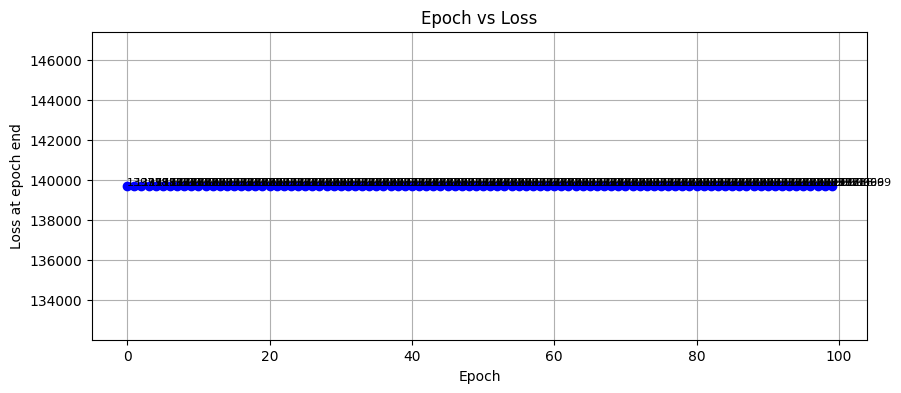

run_time:  997


127.0.0.1 - - [04/Jul/2025 21:09:21] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:22] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:23] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:24] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:25] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:26] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:27] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:28] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:29] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:30] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:31] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:32] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:33] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:34] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:35] "GET /vars HTTP/1.1" 200 -
127.0.0.1 - - [04/Jul/2025 21:09:36] "GE

In [ ]:
mdl_cfg = OmegaConf.load("model.yaml")
lrn_cfg = OmegaConf.load("hyper_params.yaml")

model = NN.create_network(mdl_cfg)
trained_model, run_time, loss_over_time_xy = train(lrn_cfg, mdl_cfg, model)
print("run_time: ", run_time)

In [ ]:
import matplotlib.pyplot as plt


for index, blocks in enumerate(trained_model.blocks):
    print(blocks.activations.shape)

f = open(lrn_cfg.images_path, 'rb')
f.read(16)
l = open(lrn_cfg.labels_path,'rb')
l.read(8)
image_buffer = f.read(lrn_cfg.image_size[0] * lrn_cfg.image_size[1] * lrn_cfg.batch_size)
image_batch = np.frombuffer(image_buffer, dtype=np.uint8).astype(np.float32)
image_batch = np.reshape(image_batch, shape = (lrn_cfg.batch_size, 
                                                lrn_cfg.image_size[0], 
                                                lrn_cfg.image_size[1]))
label_buffer = l.read(lrn_cfg.batch_size)
label_pre_batch = np.frombuffer(label_buffer, dtype=np.uint8).astype(np.int64)
label_batch = label_vec_to_output(label_pre_batch)

choice = 13
image = np.asarray(image_batch[choice]).squeeze()
plt.imshow(image)
plt.show()
print("image key: ", label_batch[choice])

inlayer = image_batch[choice]
trained_model.forward(inlayer)
np.set_printoptions(precision=4, suppress=True)
print("network's guess: ", np.argmax(trained_model.blocks[-1].activations))

print(trained_model.blocks[-1].activations)


In [ ]:
print(model.blocks[4].W_delta.shape)
print(model.blocks[4].W_delta)


In [ ]:
item = model.blocks
print("blocks")
for items in item:
    print(items.activations.shape, items.index, items.b_type)
    name = f"block_{items.index}_Activations"
    globals()[name] = items.activations


